In [1]:
!pip install bertopic sentence-transformers umap-learn hdbscan corus pymorphy3 gensim scikit-learn matplotlib seaborn plotly

Импорт библиотек и фиксация случайности

In [2]:
import os
import re
import random
import numpy as np
import pandas as pd
from functools import lru_cache
from pymorphy3 import MorphAnalyzer
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from gensim.parsing.preprocessing import STOPWORDS as GENSIM_STOPWORDS

from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance

import torch
print(f"GPU Available: {torch.cuda.is_available()}")

from corus import load_lenta

# Фиксация random_state для воспроизводимости
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

GPU Available: True


In [4]:
!wget -q https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz

In [5]:
# Переиспользуем загрузку датасета из предыщих домашних заданий
records = list(load_lenta('lenta-ru-news.csv.gz'))
df = pd.DataFrame(records)
print(f"Всего статей: {len(df)}")
df.head()


Всего статей: 739351


,0,1,2,3,4,5
0,https://lenta.ru/news/2018/12/14/cancer/,Названы регионы России с самой высокой смертно...,Вице-премьер по социальным вопросам Татьяна Го...,Россия,Общество,None
1,https://lenta.ru/news/2018/12/15/doping/,Австрия не представила доказательств вины росс...,Австрийские правоохранительные органы не предс...,Спорт,Зимние виды,None
2,https://lenta.ru/news/2018/12/15/disneyland/,Обнаружено самое счастливое место на планете,Сотрудники социальной сети Instagram проанализ...,Путешествия,Мир,None
3,https://lenta.ru/news/2018/12/15/usa25/,В США раскрыли сумму расходов на расследование...,С начала расследования российского вмешательст...,Мир,Политика,None
4,https://lenta.ru/news/2018/12/15/integrity/,Хакеры рассказали о планах Великобритании зами...,Хакерская группировка Anonymous опубликовала н...,Мир,Общество,None


Предобработка текстов

In [8]:
df = df.rename(columns={
    0: 'url',
    1: 'title',
    2: 'text',
    3: 'country',
    4: 'category',
    5: 'tags'
})

In [11]:
import re
import tqdm
from functools import lru_cache
from pymorphy3 import MorphAnalyzer

# Инициализация морфологического анализатора
morph = MorphAnalyzer()

# Базовый список русских стоп-слов (можно расширить при необходимости)
RU_STOPWORDS = {
    'и', 'в', 'во', 'не', 'на', 'я', 'его', 'мне', 'с', 'как', 'он', 'это', 'что',
    'у', 'же', 'вы', 'бы', 'по', 'только', 'ее', 'она', 'они', 'да', 'уж', 'но',
    'ни', 'о', 'а', 'из', 'за', 'к', 'под', 'от', 'до', 'для', 'без', 'при',
    'где', 'кто', 'когда', 'если', 'то', 'ли', 'бы', 'был', 'была', 'было', 'были',
    'мы', 'наш', 'ваш', 'тот', 'эта', 'этот', 'эти', 'весь', 'все', 'всё', 'всеми'
}

# Кэширование результатов лемматизации для ускорения работы на больших датасетах
@lru_cache(maxsize=100_000)
def lemmatize_cached(word: str) -> str:
    return morph.parse(word)[0].normal_form

def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # Приведение к нижнему регистру и удаление URL
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Удаление цифр, пунктуации и спецсимволов (оставляем кириллицу, латиницу и пробелы)
    text = re.sub(r'[^\а-яёa-z\s]', ' ', text)

    # Нормализация пробелов
    text = re.sub(r'\s+', ' ', text).strip()

    if not text:
        return ""

    # Токенизация, фильтрация стоп-слов/коротких слов и лемматизация
    tokens = text.split()
    return " ".join([lemmatize_cached(w) for w in tokens if len(w) > 2 and w not in RU_STOPWORDS])

# Ограничиваем датасет до 100 000 элементов для скорости
N_SAMPLES = 100_000
df_subset = df.head(N_SAMPLES)

print(f"Начинаем предобработку {len(df_subset)} документов...")

docs_clean = [
    preprocess_text(txt)
    for txt in tqdm.tqdm(df_subset['text'].values, desc="Очистка и лемматизация")
]

# Фильтруем документы, которые стали слишком короткими после удаления стоп-слов и цифр
# Порог > 3 токена позволяет отсечь мусор, но не удаляет короткие осмысленные новости
docs_clean = [doc for doc in docs_clean if len(doc.split()) > 3]

print(f"Предобработка завершена. Документов для обучения: {len(docs_clean)}")

Начинаем предобработку 100000 документов...


Очистка и лемматизация: 100%|██████████| 100000/100000 [02:08<00:00, 778.68it/s]


Предобработка завершена. Документов для обучения: 100000


Проектирование пайплайна BERTopic

Энкодер: cointegrated/rubert-tiny2. Оптимизирован для русского языка, легкий, быстро работает на GPU, дает качественные семантические эмбеддинги без переобучения.

Снижение размерности: UMAP. В отличие от PCA, UMAP сохраняет как локальную, так и глобальную структуру данных, что критически важно для плотностной кластеризации.

In [12]:
embedding_model = SentenceTransformer("cointegrated/rubert-tiny2")

# UMAP (сохраняет структуру + ускоряет HDBSCAN)
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=SEED
)

# HDBSCAN (плотностная кластеризация)
cluster_model = HDBSCAN(
    min_cluster_size=30,  # Будет обосновано ниже
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# Векторизатор (CountVectorizer + стоп-слова)
vectorizer_model = CountVectorizer(stop_words="english", min_df=2)

# Представление тем (MMR для разнообразия)
representation_model = MaximalMarginalRelevance(diversity=0.6)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Настройка гиперпараметров и обучение

min_cluster_size=30: При ~10k документах слишком маленькие кластеры будут шумом, а слишком большие "схлопнут" нишевые темы. 30-50 — оптимальный баланс.

min_df=2: Игнорирует слова, встречающиеся только в одном документе, снижая шум в c-TF-IDF.

In [14]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    calculate_probabilities=True,
    verbose=True
)

print("Запуск обучения BERTopic (может занять несколько минут)...")
topics, probs = topic_model.fit_transform(docs_clean)
print(f"Обучение завершено. Найдено тем: {len(set(topics)) - 1}")

2026-04-05 12:20:07,769 - BERTopic - Embedding - Transforming documents to embeddings.


Запуск обучения BERTopic (может занять несколько минут)...


Batches:   0%|          | 0/3125 [00:00<?, ?it/s]

2026-04-05 12:22:43,120 - BERTopic - Embedding - Completed ✓
2026-04-05 12:22:43,123 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-05 12:25:50,249 - BERTopic - Dimensionality - Completed ✓
2026-04-05 12:25:50,254 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-05 12:32:14,737 - BERTopic - Cluster - Completed ✓
2026-04-05 12:32:14,774 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-05 12:32:30,979 - BERTopic - Representation - Completed ✓


Обучение завершено. Найдено тем: 291


Визуализация результатов

Визуализация результатов BERTopic...

1. Топ-токены для топ-тем...



2. Расположение тем в 2D пространстве...



3. Распределение документов по темам...


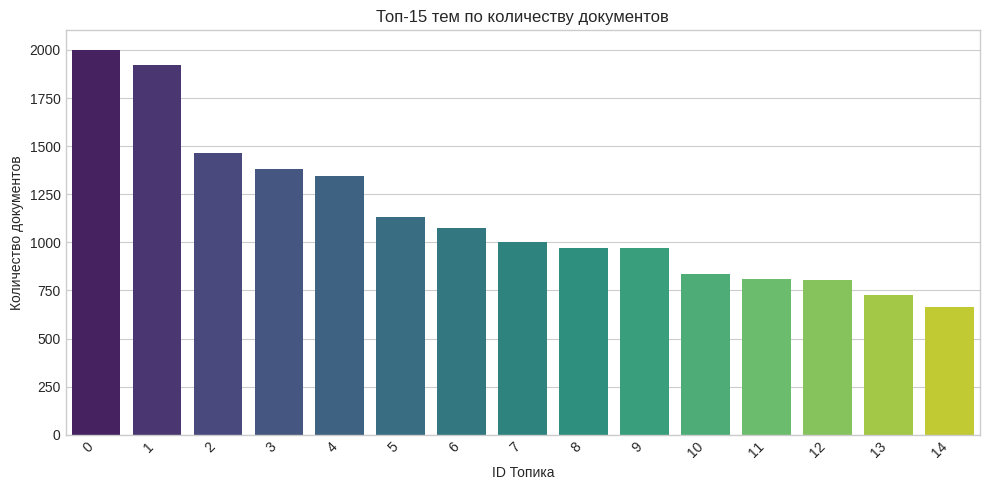


✅ Визуализация завершена!


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.offline import iplot
import numpy as np
import pandas as pd

print("Визуализация результатов BERTopic...\n")

print("1. Топ-токены для топ-тем...")
fig_bar = topic_model.visualize_barchart(top_n_topics=15, n_words=8)
iplot(fig_bar)


print("\n2. Расположение тем в 2D пространстве...")
fig_topics = topic_model.visualize_topics()
iplot(fig_topics)



print("\n3. Распределение документов по темам...")
topic_counts = pd.Series(topic_model.topics_).value_counts().sort_values(ascending=False)
topic_counts = topic_counts[topic_counts.index != -1]  # Убираем выбросы (-1)

plt.figure(figsize=(10, 5))
sns.barplot(x=topic_counts.index.astype(str)[:15], y=topic_counts.values[:15], palette="viridis")
plt.xlabel("ID Топика")
plt.ylabel("Количество документов")
plt.title("Топ-15 тем по количеству документов")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n✅ Визуализация завершена!")

Оценка формального качества

In [26]:
topic_info = topic_model.get_topic_info()

# Topic Diversity
# Собираем топ-слова для каждого валидного топика (исключая выбросы -1)
# Важно брать реальные ID из topic_info, так как номера топиков могут идти не по порядку (0, 2, 5...)
valid_topics = topic_info[topic_info.Topic != -1]
topic_ids = valid_topics['Topic'].tolist()

all_top_words = []
for topic_id in topic_ids:
    topic_data = topic_model.get_topic(topic_id)

    if topic_data:
        words = [word for word, _ in topic_data]
        # Берем топ-10 слов для каждого топика
        all_top_words.extend(words[:10])

# Расчет разнообразия: (кол-во уникальных слов) / (общее кол-во слов) * 100
if all_top_words:
    topic_diversity = len(set(all_top_words)) / len(all_top_words) * 100
    print(f"Topic Diversity: {topic_diversity:.2f}%")
else:
    print("Topic Diversity: 0.00%")


# UMass Coherence через Gensim
# Токенизируем документы (используем уже очищенные docs_clean)
tokenized_docs = [doc.split() for doc in docs_clean]

topics_dict = topic_model.get_topics()

topics_for_gensim = []
for topic_id, word_scores in topics_dict.items():
    # Исключаем выбросы (обычно id -1) и пустые топики
    if topic_id != -1 and word_scores:
        # word_scores - это список кортежей, нам нужны только слова
        words_only = [word for word, score in word_scores]
        topics_for_gensim.append(words_only)

# Строим словарь и считаем когерентность
if topics_for_gensim and tokenized_docs:
    dictionary = Dictionary(tokenized_docs)
    # Фильтруем очень редкие и слишком частые слова для стабильности метрики
    dictionary.filter_extremes(no_below=2, no_above=0.8)

    coherence_model = CoherenceModel(
        topics=topics_for_gensim,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='u_mass'
    )
    umass_coherence = coherence_model.get_coherence()
    print(f"📈 UMass Coherence: {umass_coherence:.4f}")
else:
    print("Невозможно вычислить Coherence (нет валидных топиков или документов).")

Topic Diversity: 59.66%
📈 UMass Coherence: -2.9560


 UMass Coherence от -2 до -4 - хорошее значение для русского языка с богатой морфологией это ожидаемо